In [1]:
using GLMakie

In [2]:
fs = [5.00, 3.11, 2.00, 1.55, 1.20,0.903, 0.769,0.500,0.378,0.280,0.219,0.183,0.171,0.158,0.146,0.134,0.122,0.109,0.098,0.085,0.073,0.061,0.049,0.036,0.024,0.012]*1e6;
RMS = [0.72, 0.72,0.71, 0.71, 0.71, 0.70, 0.70, 0.69, 0.68, 0.65, 0.63, 0.60, 0.59, 0.58, 0.56, 0.54, 0.52, 0.49, 0.46, 0.43, 0.39, 0.35, 0.29, 0.24, 0.16, 0.08 ];

In [3]:
H(f,fc) = f/(sqrt(f^2+fc^2))

H (generic function with 1 method)

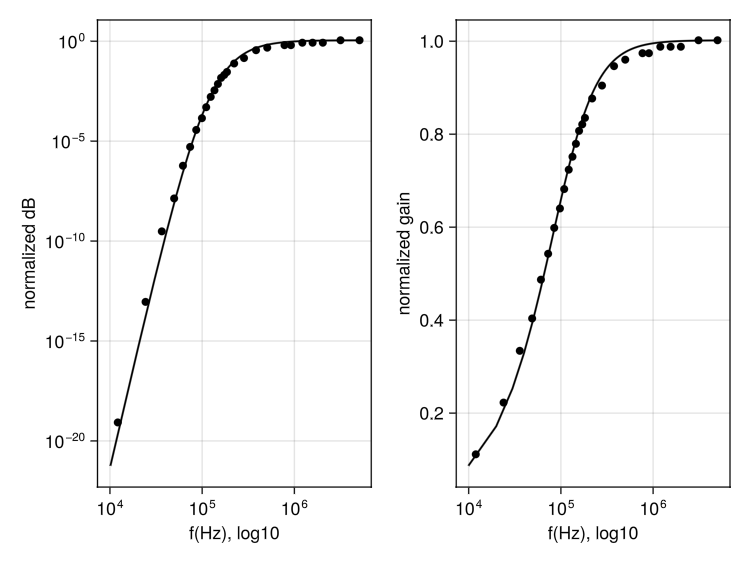

In [4]:
fc = 115e3
G = 0.72
fig = Figure()
ax = Axis(fig[1,1],xscale=log10,yscale=log10,xlabel="f(Hz), log10",ylabel="normalized dB")
scatter!(ax,fs,(RMS/G).^20,color=:black)
lines!(ax,10e3:10e3:5e6, H.(10e3:10e3:5e6,fc).^20,color=:black)

ax = Axis(fig[1,2],xscale=log10,xlabel="f(Hz), log10",ylabel="normalized gain")
scatter!(ax,fs,RMS/G,color=:black)
lines!(ax,10e3:10e3:5e6, H.(10e3:10e3:5e6,fc),color=:black)
fig

In [5]:
RMS_mean = sum(RMS)/length(RMS);
Hs = H.(fs,fc)*G;
SS_res = sum((RMS-Hs).^2);
SS_tot = sum((RMS .- RMS_mean).^2);
R2 = 1 - SS_res/SS_tot

0.9971714074203017